In [3]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

没有固定

读取数据并调整顺序

In [4]:
# 读取数据
model_data_path = '../data/processed/merged_dataset_cleaned.csv'
model_df = pd.read_csv(model_data_path)

def add_interaction_terms(df, spei_lag_var):
    """
    添加 SPEI 滞后变量的交互项。
    
    Parameters:
    df: pd.DataFrame
        数据框
    spei_lag_var: str
        SPEI 滞后变量的列名
    
    Returns:
    pd.DataFrame
        添加交互项后的数据框
    """
    df['spei_ma_interact'] = df[spei_lag_var] * df['o_MA']
    df['spei_bf_interact'] = df[spei_lag_var] * df['border_friction_ij']
    return df

model_df = add_interaction_terms(model_df, 'spei_lag1')



In [5]:
# 按照指定顺序调整列顺序并删除
ordered_columns = [
    # ISO 列
    'origin_iso3', 'destination_iso3',
    # 日期相关
    'migration_date', 'year', 'month',
    # 因变量
    'flow', 'log_flow',
    # 重点自变量
    'o_spei', 'spei_lag1', 'spei_lag2', 'spei_lag3', 'o_MA', 'border_friction_ij',
    # 交互项
    'spei_ma_interact', 'spei_bf_interact',
    # 控制变量
    'o_gdp_pc', 'd_gdp_pc', 'o_pop', 'd_pop', 'o_urban', 'd_urban',
    'o_unemp', 'd_unemp', 'o_political_stability', 'd_political_stability',
    'control_distwces'
]

# 重新排列列顺序
model_df = model_df[ordered_columns]

#### 1. 数据质量检查

#####  检查是否还有缺失值

In [6]:
print(model_df.isnull().sum())

origin_iso3              0
destination_iso3         0
migration_date           0
year                     0
month                    0
flow                     0
log_flow                 0
o_spei                   0
spei_lag1                0
spei_lag2                0
spei_lag3                0
o_MA                     0
border_friction_ij       0
spei_ma_interact         0
spei_bf_interact         0
o_gdp_pc                 0
d_gdp_pc                 0
o_pop                    0
d_pop                    0
o_urban                  0
d_urban                  0
o_unemp                  0
d_unemp                  0
o_political_stability    0
d_political_stability    0
control_distwces         0
dtype: int64


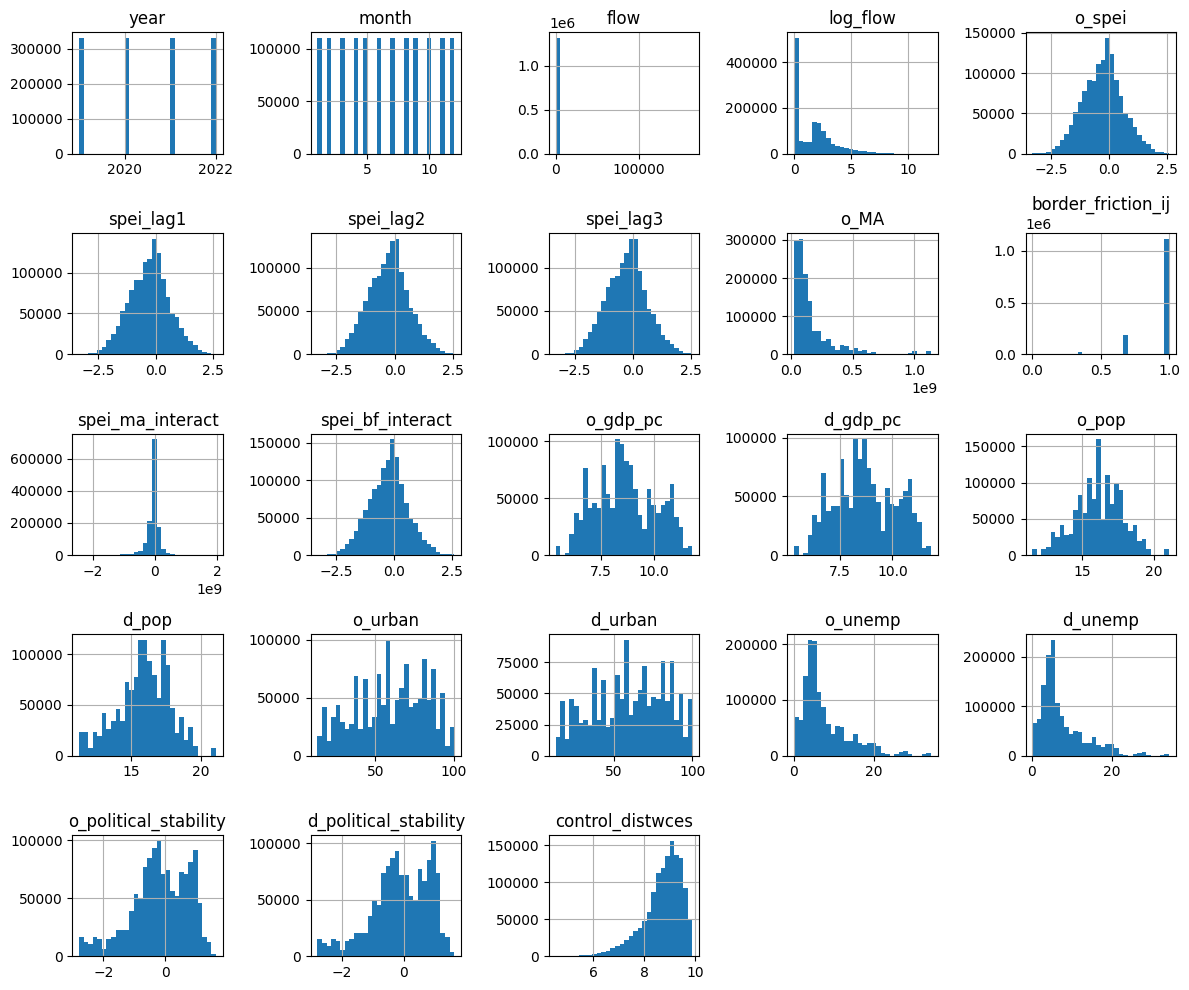

In [7]:
# 检查数据分布和异常值
valuable_columns = [
    'year',
    'month',
    'flow',  # 迁移流
    'log_flow',  # 迁移流的对数值
    'o_spei',  # 干旱指数
    'spei_lag1',  # 干旱指数滞后一期
    'spei_lag2',  # 干旱指数滞后两期
    'spei_lag3',  # 干旱指数滞后三期
    'o_MA',  # Market Access
    'border_friction_ij',  # 边境摩擦
    'spei_ma_interact',  # 干旱指数与市场接入的交互项
    'spei_bf_interact',  # 干旱指数与边境摩擦的交互项
    'o_gdp_pc',  # 出发国 GDP per capita
    'd_gdp_pc',  # 目的国 GDP per capita
    'o_pop',  # 出发国人口
    'd_pop',  # 目的国人口
    'o_urban',  # 出发国城市化率
    'd_urban',  # 目的国城市化率
    'o_unemp',  # 出发国失业率
    'd_unemp',  # 目的国失业率
    'o_political_stability',  # 出发国政治稳定性
    'd_political_stability',  # 目的国政治稳定性
    'control_distwces'  # 控制变量：距离
]

# 绘制选定变量的直方图
model_df[valuable_columns].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

##### 时间变量处理
生成 唯一的时间 ID（方便做时间固定效应）：

In [8]:
# 创建 time_id，从 2019 年开始的连续数字
model_df['time_id'] = (
    (pd.to_datetime(model_df['migration_date']).dt.year - 2019) * 12 +
    pd.to_datetime(model_df['migration_date']).dt.month
)

##### 3. 双边 ID 创建
固定效应要区分国家对：

In [9]:
# 创建双边 ID（数字形式）
model_df['pair_id'] = model_df.groupby(['origin_iso3', 'destination_iso3']).ngroup()

In [10]:
model_df

,origin_iso3,destination_iso3,migration_date,year,month,flow,log_flow,o_spei,spei_lag1,spei_lag2,...,d_pop,o_urban,d_urban,o_unemp,d_unemp,o_political_stability,d_political_stability,control_distwces,time_id,pair_id
0,ARE,AND,2019-01-01,2019,1,0,0.000000,0.013769,0.345254,-0.196752,...,11.244706,86.789,87.984,2.236,5.542,0.667538,-0.091492,8.563920,1,522
1,ARE,AND,2019-02-01,2019,2,12,2.564949,-0.017917,0.013769,0.345254,...,11.244706,86.789,87.984,2.236,5.542,0.667538,-0.091492,8.563920,2,522
2,ARE,AND,2019-03-01,2019,3,0,0.000000,0.490999,-0.017917,0.013769,...,11.244706,86.789,87.984,2.236,5.542,0.667538,-0.091492,8.563920,3,522
3,ARE,AND,2019-04-01,2019,4,1,0.693147,0.797000,0.490999,-0.017917,...,11.244706,86.789,87.984,2.236,5.542,0.667538,-0.091492,8.563920,4,522
4,ARE,AND,2019-05-01,2019,5,3,1.386294,0.580897,0.797000,0.490999,...,11.244706,86.789,87.984,2.236,5.542,0.667538,-0.091492,8.563920,5,522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319781,ZWE,ZMB,2022-08-01,2022,8,138,4.934474,0.326137,0.494725,0.959915,...,16.818861,32.395,45.761,9.540,5.199,-0.894974,0.161332,6.263538,44,27496
1319782,ZWE,ZMB,2022-09-01,2022,9,162,5.093750,-0.502948,0.326137,0.494725,...,16.818861,32.395,45.761,9.540,5.199,-0.894974,0.161332,6.263538,45,27496
1319783,ZWE,ZMB,2022-10-01,2022,10,149,5.010635,-0.593602,-0.502948,0.326137,...,16.818861,32.395,45.761,9.540,5.199,-0.894974,0.161332,6.263538,46,27496
1319784,ZWE,ZMB,2022-11-01,2022,11,104,4.653960,-0.331173,-0.593602,-0.502948,...,16.818861,32.395,45.761,9.540,5.199,-0.894974,0.161332,6.263538,47,27496


In [11]:
print(model_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319786 entries, 0 to 1319785
Data columns (total 28 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   origin_iso3            1319786 non-null  object 
 1   destination_iso3       1319786 non-null  object 
 2   migration_date         1319786 non-null  object 
 3   year                   1319786 non-null  int64  
 4   month                  1319786 non-null  int64  
 5   flow                   1319786 non-null  int64  
 6   log_flow               1319786 non-null  float64
 7   o_spei                 1319786 non-null  float64
 8   spei_lag1              1319786 non-null  float64
 9   spei_lag2              1319786 non-null  float64
 10  spei_lag3              1319786 non-null  float64
 11  o_MA                   1319786 non-null  float64
 12  border_friction_ij     1319786 non-null  float64
 13  spei_ma_interact       1319786 non-null  float64
 14  spei_bf_interact  

#### 2. 探索性数据分析 (EDA)
通过可视化和统计分析，了解数据的基本特征：

<Axes: title={'center': 'Yearly Migration Flow'}, xlabel='year'>

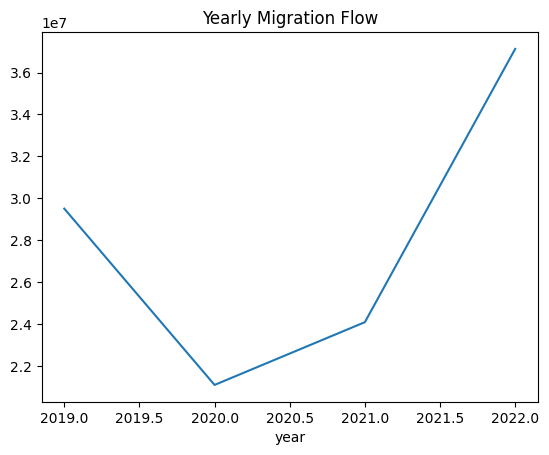

In [12]:
model_df.groupby('year')['flow'].sum().plot(kind='line', title='Yearly Migration Flow')

##### 相关性分析：检查变量之间的相关性

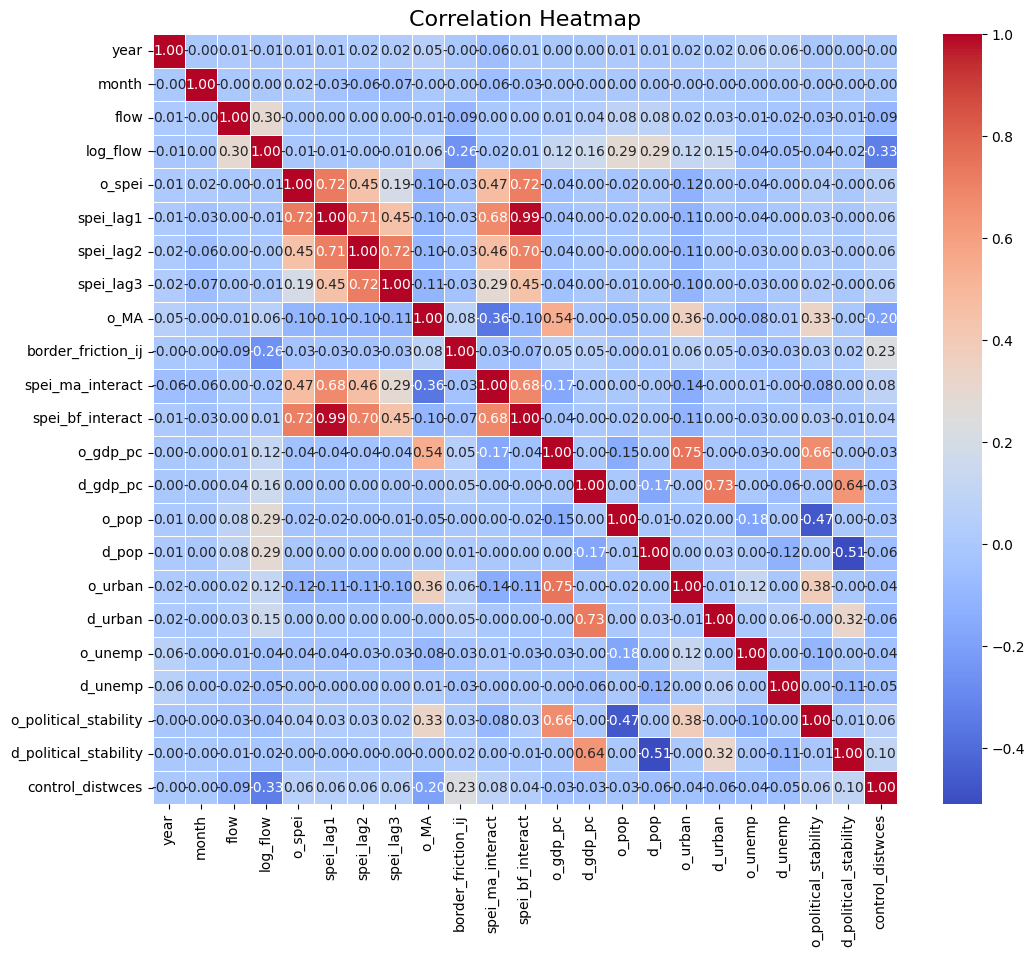

In [13]:
# 过滤掉包含 'xxx_was_missing' 的列和两个 ID 列
exclude_columns = ['pair_id', 'time_id']  # 两个 ID 列
numeric_cols = model_df.select_dtypes(include=[np.number])
filtered_cols = [col for col in numeric_cols.columns if 'was_missing' not in col and col not in exclude_columns]

# 只选择数值列
corr = numeric_cols[filtered_cols].select_dtypes(include=[np.number]).corr()

# 绘制热力图，调整图表大小
plt.figure(figsize=(12, 10))  # 调整宽度和高度
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

#### 3. 模型搭建

In [14]:
# === 数据准备 ===
# 确保数据是多重索引格式（PanelOLS 需要）
model_df = model_df.set_index(['pair_id', 'time_id'])


##### 模型定义

In [15]:
# 控制变量
controls = [
    'o_gdp_pc', 'd_gdp_pc',
    'o_pop', 'd_pop',
    'o_urban', 'd_urban',
    'o_unemp', 'd_unemp',
    'o_political_stability', 'd_political_stability',
    'control_distwces',
    'border_friction_ij',
    'o_MA'
]

# Baseline 模型
baseline_formula = 'log_flow ~ spei_lag1 + ' + ' + '.join(controls)

# 模型 2：+ o_MA 和交互项
model_2_formula = 'log_flow ~ spei_lag1 + o_MA + spei_ma_interact + ' + ' + '.join(controls)

# 模型 3：+ border_friction_ij 和交互项
model_3_formula = 'log_flow ~ spei_lag1 + border_friction_ij + spei_bf_interact + ' + ' + '.join(controls)

# 模型 4：完整模型
model_4_formula = (
       'log_flow ~ spei_lag1 + o_MA + border_friction_ij + spei_ma_interact + spei_bf_interact + ' +
    ' + '.join(controls)
)

##### 回归分析

In [16]:
# 定义固定效应
model_df['pair_fe'] = model_df.index.get_level_values('pair_id')
model_df['time_fe'] = model_df.index.get_level_values('time_id')


In [17]:
# 运行回归
models = {}
for name, formula in zip(
    ['Baseline', 'Model 2', 'Model 3', 'Model 4'],
    [baseline_formula, model_2_formula, model_3_formula, model_4_formula]
):
    models[name] = PanelOLS.from_formula(
        formula,
        data=model_df,
        drop_absorbed=True
    ).fit(cov_type='clustered', cluster_entity=True)



In [18]:
# === 输出回归结果 ===
# 打印每个模型的回归结果
for name, model in models.items():
    print(f"=== {name} ===")
    print(model.summary)

=== Baseline ===
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                        0.3608
Estimator:                   PanelOLS   R-squared (Between):              0.5207
No. Observations:             1319786   R-squared (Within):              -0.0005
Date:                Wed, Aug 13 2025   R-squared (Overall):              0.3608
Time:                        22:45:51   Log-likelihood                -2.346e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   5.731e+04
Entities:                       27497   P-value                           0.0000
Avg Obs:                       47.997   Distribution:              F(13,1319772)
Min Obs:                       22.000                                           
Max Obs:                       48.000   F-statistic (robust):             1460.5
           

In [19]:
# === 输出回归结果 ===
# 汇总结果表
results_table = summary_col(
    [models['Baseline'], models['Model 2'], models['Model 3'], models['Model 4']],
    stars=True,
    model_names=['Baseline', 'Model 2', 'Model 3', 'Model 4'],
    info_dict={'R²': lambda x: f"{x.rsquared:.3f}", 'N': lambda x: f"{x.nobs}"}
)
print(results_table)

AttributeError: 'PanelEffectsResults' object has no attribute 'bse'

In [ ]:
# === 可视化交互效应 ===
# 计算边际效应
def marginal_effect_plot(model, interaction_var, moderator_var, moderator_values, xlabel, ylabel, title):
    marginal_effects = []
    for value in moderator_values:
        df_temp = df_merged.copy()
        df_temp[moderator_var] = value
        marginal_effect = model.params['o_spei'] + model.params[f'o_spei:{moderator_var}'] * value
        marginal_effects.append(marginal_effect)

    # 绘图
    plt.figure(figsize=(8, 6))
    plt.plot(moderator_values, marginal_effects, marker='o')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.5)
    plt.show()

# 可视化 MA 的交互效应
marginal_effect_plot(
    models['Model 2'],
    interaction_var='o_spei:o_MA',
    moderator_var='o_MA',
    moderator_values=np.linspace(df_merged['o_MA'].min(), df_merged['o_MA'].max(), 10),
    xlabel='Market Access (MA)',
    ylabel='Marginal Effect of SPEI on log_flow',
    title='Marginal Effect of SPEI on log_flow by MA'
)

# 可视化 Border Friction 的交互效应
marginal_effect_plot(
    models['Model 3'],
    interaction_var='o_spei:border_friction_ij',
    moderator_var='border_friction_ij',
    moderator_values=np.linspace(df_merged['border_friction_ij'].min(), df_merged['border_friction_ij'].max(), 10),
    xlabel='Border Friction',
    ylabel='Marginal Effect of SPEI on log_flow',
    title='Marginal Effect of SPEI on log_flow by Border Friction'
)